# Orthogonality and projections

## 1. Retrieval

1. What does the dot product of two vectors calculate?

> The dot product is the sum of the products of corresponding components. Its sign and magnitude reflect how strongly two vectors align, although the magnitude also depends on their lengths.

2. What does the norm of a vector represent?

> The distance from the point of the vector to the origin (i.e. its magnitude)

3. What does rank 1 mean geometrically for a `2 × 2` matrix?

> The column vectors are linearly dependent and therefore span a one-dimensional subspace (a line through the origin) within $\R ^2$

4. Why can a matrix with determinant zero not have an inverse?

> Transforming by a matrix with determinant of zero will cause the output vector to be mapped onto a lower dimensional space than the input vector, and no function exists that undoes this collapse of vector space therefore an inverse of the matrix cannot exist

5. What is the difference between calculating `np.linalg.inv(a)` and using `np.linalg.solve(a, b)`?

> `np.linalg.inv(a)` calculates the inverse matrix of a which is the matrix that reverse the transformation performed by A, while `np.linalg.solve(A, b)` directly finds the input vectors that map to b when transformed by A

## 2. Learn

### Orthogonality:

Non-zero vectors are orthogonal if their dot product is zero. This means that the lines that they sit on are perpendicular to each other.

### Unit vectors:

A vector that has length (or magnitude) of 1. It points in a specific direction but carries no other scaling factor.

### Normalisation:

Normalisation changes a vectors magnitude to 1 while preserving its direction. A non-zero vector is normalised by dividing by its magnitude (for a two-dimensional vector $||u|| = \sqrt{a^2+b^2}$ ), therefore:

$\hat{u} = \frac{u}{||u||}$

### Vector projections:

The vector projection of a vector `u` onto a non-zero vector `v` is the vector representing the "shadow" of `u` along the line spanned by `v`. It is parallel to `v` and is calculated using:

$\ proj_v(u) = \frac{u \cdot v}{v \cdot v}\cdot v$

The result is a vector parallel to `v`, representing the component of `u` along the line spanned by `v`

### Projection matrices

A projection matrix `P` is a square matrix associated to a linear operator that maps vectors into their projections onto a subspace. The matrix projecting vectors onto the line spanned by unit vector $\hat{u}$ is:

$\ P = \hat{u}\hat{u}^T$

## 3. Guided concept check

Start with:

In [1]:
import numpy as np

u = np.array([3, 4])
v = np.array([4, -3])
w = np.array([1, 2])

Before running code, answer:

1. What is u @ v?

> $\ 3 \times 4 + 4 \times -3 = 0 $

2. Based on that result, what geometric relationship do you expect between u and v?

> u and v are orthogonal

3. What is the norm of u?

> $\ ||u|| = \sqrt{3^2 + 4^2} = 5$


4. What shape should the normalised version of u have?

> The same shape as u: (2,)

5. Should normalising a vector change its direction, magnitude, or both?

> Normalised vector will have the same direction as the original but with a magnitude scaled to equal 1

Then verify your predictions using NumPy.

In [2]:
magnitude_u = np.linalg.norm(u)
normalised_u = u / np.linalg.norm(u)

print(u @ v)
print(magnitude_u)
print(normalised_u.shape)

0
5.0
(2,)


## 4. Main practical task: Decompose a vector

Use:

In [3]:
a = np.array([4, 3])
b = np.array([2, 1])

### Part A — normalise the direction

Calculate a unit vector pointing in the direction of b.

Before running the calculation, predict:

- the output shape;
  - > (2,)
- the expected norm of the result;
  - > 1
- whether its direction should differ from b.
  - > Direction should be the same as b

Verify its norm with np.linalg.norm().

In [4]:
normalised_b = b / np.linalg.norm(b)
print(normalised_b.shape)
print(np.allclose(np.linalg.norm(normalised_b), 1))

(2,)
True


### Part B — calculate the projection

Calculate the projection of a onto b using the projection formula.

The output should be:

- one NumPy array;
- shape (2,);
- parallel to b.

Do not use a projection matrix yet.

In [5]:
proj_a_onto_b = ((a @ b) / (b @ b)) * b
print(proj_a_onto_b)
print(proj_a_onto_b.shape)
print('Parallel to b:', (proj_a_onto_b / b)[0] == (proj_a_onto_b / b)[1]) # not sure this is a valid prrof that the projection is parallel to b

[4.4 2.2]
(2,)
Parallel to b: True


### Part C — calculate the residual

Calculate:

In [6]:
residual = a - proj_a_onto_b

Verify these two properties:

`np.allclose(projection + residual, a)`

and:

`np.isclose(residual @ b, 0)`

Then explain what each check demonstrates.

In [7]:
print(np.allclose(proj_a_onto_b + residual, a))
print(np.isclose(residual @ b, 0))

True
True


> First checks that the vector `a` is equal to the projection of `a` onto vector `b` + the residual of `a`. This makes sense that this property is true since residual is the part of `a` not captured by the projection and is calculated as:
>
> $ r = a - proj_b(a)$
>
> which can be rearranged as:
>
> $ a = r + proj_b(a)$

> Second check demonstrates that the residual of `a` is orthogonal to `b` 


### Part D — compare vector lengths

Calculate the norms of:

- `a`;
- the projection;
- the residual.

Write one sentence explaining why the projection cannot be longer than `a` in this example.

In [8]:
print(np.linalg.norm(a))
print(np.linalg.norm(proj_a_onto_b))
print(np.linalg.norm(residual))

5.0
4.919349550499538
0.8944271909999159


Geometry can be used to explain why the projection cannot be longer than `a`: when `a` is projected on `b` it forms a right-angle triangle, with `a` forming the hypotenuse, the projection forming the adjacent (with respect to the angle formed between `a` and `b`), and the opposite formed by the line between the point of `a` that is perpendicular to `b`. Since the hypotenuse is the longest side of a right-angle triangle, `a` must be longer than the projection

## 5. Projection matrix

Construct the projection matrix using your unit direction vector:

`P = unit_b × unit_bᵀ`

Use `np.outer()`.

Then:

1. print P;
2. print its shape;
3. calculate P @ a;
4. compare the result with your earlier projection;
5. verify that P @ P is equal to P;
6. verify that P.T is equal to P.

In [9]:
P = np.outer(normalised_b, normalised_b)

print('Projection matrix P:\n', P)
print('P shape:', P.shape)

x = P @ a
print('P @ a == proj_a_onto_b:', np.allclose(x, proj_a_onto_b))
print('P @ P == P:', np.allclose(P @ P, P))
print('P.T == P:', np.allclose(P.transpose(), P))

Projection matrix P:
 [[0.8 0.4]
 [0.4 0.2]]
P shape: (2, 2)
P @ a == proj_a_onto_b: True
P @ P == P: True
P.T == P: True


Explain why:

`P @ P = P`

means projecting an already projected vector does not change it.

> $x = Pa$
>
> $Px = P(Pa) = (p^2)a = Pa = x$
>
> Once a vector has been projected, it already lies in the target subspace. Since $\ P^2=P $, applying P again produces the same projected vector.

Explain why:

`P.T = P`

shows that this projection matrix is symmetric.

> Taking the transpose of a square matrix keeps the diagonal top-left -> bottom-right diagonal components in place while mirroring all other values along this diagonal axis. If `P.T = P`, reflecting the entries across the main diagonal leaves the matrix unchanged, which is the definition of a symmetric matrix.

## 6. Project a collection of points

Use:

In [10]:
points = np.array([
    [3, 4],
    [4, 1],
    [-2, 3],
    [1, -3],
    [-4, -1],
    [2, 2]
])

Each row is one two-dimensional point.

Project every point onto the line spanned by `b`.

In [11]:

projected_points = points @ P.transpose()

print('Projected points:\n', projected_points)

Projected points:
 [[ 4.   2. ]
 [ 3.6  1.8]
 [-0.4 -0.2]
 [-0.4 -0.2]
 [-3.6 -1.8]
 [ 2.4  1.2]]


Then:

1. confirm that projected_points has shape (6, 2);
2. calculate the residual vector for each point;
3. verify that every residual is orthogonal to b;
4. verify that each original point equals its projection plus its residual.

In [12]:
# 1.
print('Projected points shape:', projected_points.shape)

# 2.
residuals = points - projected_points
print('Residuals:', residuals)

# 3.
print('Residuals orthogonal to b:', np.allclose(residuals @ b, 0))
print('residuals @ b shape:', (residuals @ b).shape)

# 4.
print('Original point == projection + residual:', np.allclose(points, projected_points + residuals))

Projected points shape: (6, 2)
Residuals: [[-1.   2. ]
 [ 0.4 -0.8]
 [-1.6  3.2]
 [ 1.4 -2.8]
 [-0.4  0.8]
 [-0.4  0.8]]
Residuals orthogonal to b: True
residuals @ b shape: (6,)
Original point == projection + residual: True


## 7. Visualisation

Create one plot containing:

- the original points;
- the projected points;
- a line showing the direction onto which they were projected;
- a connecting segment from each original point to its projection;
- labelled axes;
- equal scaling on both axes.

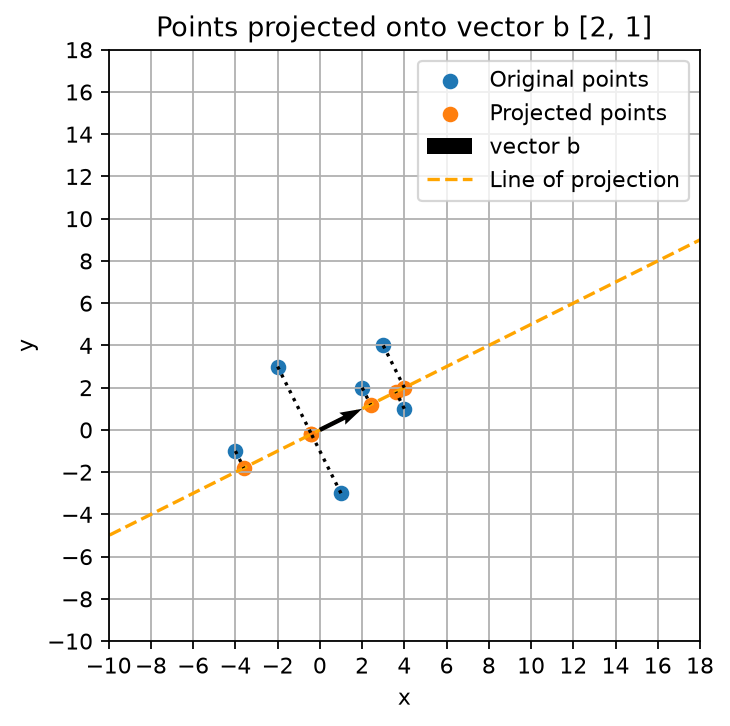

In [13]:
import matplotlib.pyplot as plt

points_T = points.transpose()
projected_T = projected_points.transpose()
x = np.arange(-20,20)

# function for line vector b lies on
def f(x):
  return x / 2

fig, ax = plt.subplots()

ax.scatter(
  points_T[0], 
  points_T[1], 
  label='Original points'
)
ax.scatter(
  projected_T[0], 
  projected_T[1], 
  label='Projected points'
)
ax.quiver(
  [0], 
  [0], 
  [2], 
  [1], 
  angles='xy', 
  scale_units='xy', 
  scale=1,
  zorder=10,
  label='vector b'
)
ax.plot(
  x, 
  f(x), 
  '--', 
  color='orange', 
  label='Line of projection'
)
ax.plot(
  [points_T[0], projected_T[0]],
  [points_T[1], projected_T[1]], 
  'k', 
  linestyle='dotted',
)

plt.grid(visible=True)
plt.axis([-10, 10, -10, 10])
plt.xticks(np.arange(-10, 20, 2))
plt.yticks(np.arange(-10, 20, 2))
ax.set_aspect('equal', adjustable='box')
ax.set_title('Points projected onto vector b [2, 1]')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
fig.set_dpi(160)

Explain:

- why all projected points lie on one line;

> Transforming a vector by the Projection matrix $\ P = \hat{b}\hat{b}^T$ collapses the vectors to lie within the one-dimensional sub-space that the vector `b` spans, i.e. on the same line as `b` . The result is that every vector transformed by `P` will therefore lie on the same line within the span of vector `b`

- why each connecting segment is perpendicular to that line;

> Each connecting segment represents the residual between an original point and its projection. Since every residual has zero dot product with `b`, each segment is perpendicular to the line spanned by `b`.

- what information is discarded by the projection.

> The residuals are discarded by the calculation of the projection


# 8. Reflection

1. What does it mean for two vectors to be orthogonal?

> They have a dot product of 0 and they span perpendicular subspaces

2. What changes when a vector is normalised?

> The magnitude of the vector becomes 1, but the direction of the vector persists

3. What is the difference between a projection and its residual?

> A projection is how one vector maps onto the span of another vector, while the residual is what is lost due to this collapse into a lower dimensional subspace

4. Why is the residual orthogonal to the projection direction?

> The projection removes exactly the component of a parallel to `b`. The remaining residual has zero dot product with `b`, so it is orthogonal to the projection direction.

5. What does the projection matrix do?

> A projection matrix maps vectors into their projections onto a subspace.

6. Which verification check was most useful?

> The check `np.isclose(residual @ b, 0)` was most useful because it directly confirmed that the residual was orthogonal to the projection direction. The plotting extension was the most useful part of the exercise overall.